In [1]:
import torch as pt


mols_test = pt.load('./data/mine/test_11499.pt')
print(len(mols_test))
mols_all = pt.load('./data/mine/mols_all.pt')
print(len(mols_all))

11499
2253216


In [3]:
# 统计词频
import numpy as np


mols_train = mols_all[:232826]
count_list = np.zeros(1000)
for mol in mols_train:
    tmp_list = np.zeros(1000)
    for mz in mol.mz:
        tmp_list[int(mz)] = 1
    count_list += tmp_list

count_list += 1  
print(count_list.shape)

(1000,)


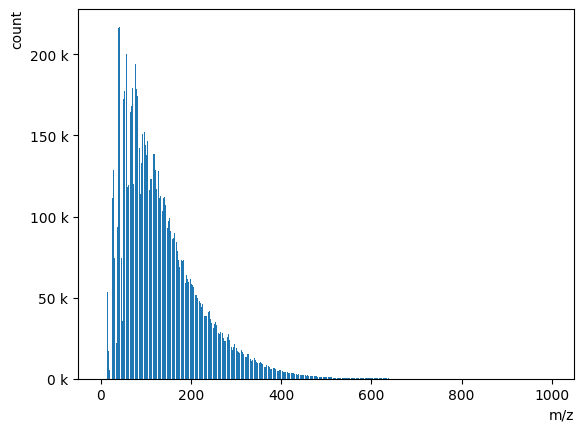

In [4]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

fig = plt.figure()
ax = fig.add_subplot()
ax.bar(np.arange(1000), count_list)
ax.set_xlabel('m/z', loc='right')
ax.set_ylabel('count', loc='top')
# ax.legend()
def formatter(x, pos):
    return f'{int(x/1000)} k'
plt.gca().yaxis.set_major_formatter(FuncFormatter(formatter))
# fig.savefig('count_bar.svg', format='svg', dpi=500)

In [5]:
import numpy as np


# 生成负采样概率
pow_frequency = np.array(count_list) ** 0.75
neg_prob = pow_frequency / pow_frequency.sum()
print(neg_prob.shape)
# 生成下采样概率
mzs_freq = np.array(count_list)
mzs_freq = mzs_freq / np.sum(mzs_freq)
t = 1e-3
keep_prob = np.array([np.sqrt(t/f) + t/f for f in mzs_freq])

(1000,)


In [6]:
from torch.utils.data import DataLoader
from utils.data import SpecDataset, collate_fun_emb
import numpy as np


def collate_fun(keep_prob:np.array, neg_prob:np.array, neg_num:int=5, min_len_mz:int=10, min_inten:float=0.01):
    neg_choice = np.arange(neg_prob.shape[0])
    def collate_fn(batch):
        # con: context, cen: center
        mzs_con, inten_con, masks_con, poss_cen, batch_idx, negs_cen, masks_neg = [], [], [], [], [], [], []
        max_len = max([len(mz) for mz, _ in batch])
        idx = 0
        for mz, inten in batch:
            len_mz = len(mz)
            if len_mz >= min_len_mz: # 移除峰的数量小于阈值的质谱 
                pad_num = max_len - len_mz
                pos_cen = []
                mask_down = np.random.random(len_mz) < keep_prob[mz]
                for i in range(len_mz):
                    if mask_down[i] and inten[i] > min_inten: # 如果没有被mask掉
                        mask_pos_down = np.array(mask_down)
                        mask_pos_down[i] = False
                        if np.any(mask_pos_down): # 上下文没有被全部mask掉
                            pos_cen.append(mz[i])
                            masks_con.append(np.pad(mask_pos_down, (0, pad_num)))
                if len(pos_cen) == 0: # 整个质谱中的中心词都被mask掉了
                    continue   
                mzs_con.append(np.pad(mz, (0, pad_num)))
                inten_con.append(np.pad(inten, (0, pad_num)))
                poss_cen.extend(pos_cen)
                batch_idx.extend([idx] * len(pos_cen))
                idx += 1
                neg_cen = np.random.choice(neg_choice, (len(pos_cen), neg_num), p=neg_prob)
                mask_neg = neg_cen != np.array(pos_cen)[:, np.newaxis]
                negs_cen.append(neg_cen)
                masks_neg.append(mask_neg)
        if len(mzs_con) == 0:
            return None
        mzs_con = pt.tensor(np.array(mzs_con), dtype=pt.long)
        inten_con = pt.tensor(np.array(inten_con), dtype=pt.float)
        masks_con = pt.tensor(np.array(masks_con), dtype=pt.bool)
        poss_cen = pt.tensor(np.array(poss_cen), dtype=pt.long)
        batch_idx = pt.tensor(np.array(batch_idx), dtype=pt.int)
        negs_cen = pt.tensor(np.concatenate(negs_cen), dtype=pt.long)
        masks_neg = pt.tensor(np.concatenate(masks_neg), dtype=pt.bool)
        return mzs_con, inten_con, masks_con, poss_cen, batch_idx, negs_cen, masks_neg
    return collate_fn


dataset_lib = SpecDataset(mols_all)
dataset_test = SpecDataset(mols_test)
loader_lib = DataLoader(dataset_lib, batch_size=1024, shuffle=False,
                        num_workers=8, collate_fn=collate_fun_emb)
loader_test = DataLoader(dataset_test, batch_size=1024, shuffle=False,
                        num_workers=8, collate_fn=collate_fun_emb)
dataset_train = SpecDataset(dataset_lib, mapping=np.arange(232826))
loader_train = DataLoader(dataset_train, batch_size=10, shuffle=True, 
                            num_workers=5, collate_fn=collate_fun(keep_prob, neg_prob))
num_batches = len(loader_train)

In [7]:
import torch as pt
import torch.nn as nn


class GaussianKernel(nn.Module):
    def __init__(self, num_kernels=1, emb_dim=300):
        super(GaussianKernel, self).__init__()
        self.sigma = nn.Parameter(pt.randn(num_kernels))
        self.miu = nn.Parameter(pt.randn(num_kernels))
        self.fc1 = nn.Linear(num_kernels, emb_dim)
        # self.fc = nn.Linear(1, emb_dim)

    def forward(self, x):
        # 将x的形状调整为 [batch_size, num_features, 1] 以便广播    
        x = x.unsqueeze(-1)    
        # 将sigma的形状调整为 [1, 1, num_kernels] 以便广播
        sigma_expanded = self.sigma.view(1, 1, -1)
        miu_expanded = self.miu.view(1, 1, -1)
        # 计算高斯核，形状为 [batch_size, num_features, num_kernels]
        x = pt.exp(-0.5 * ((x - miu_expanded) / sigma_expanded).pow(2))
        x = self.fc1(x)
        # x = self.fc(x)
        return x

# 使用示例
kernel = GaussianKernel(num_kernels=3)
x = pt.randn(32, 5)  # batch_size=32, num_features=5
output = kernel(x)  # 输出形状为 [32, 10, 3]

print(output.shape)

torch.Size([32, 5, 300])


In [8]:
import torch.optim as optim
from utils.model import Spec2Emb, Linear_Scheduler
import torch.nn as nn
import torch.nn.functional as F


class Spec2Emb(nn.Module):
    def __init__(self, num_emb:int=1000, emb_dim:int=500, num_kernels:int=3):
        super(Spec2Emb, self).__init__()
        self.max_exp = 6
        self.emb_con = nn.Embedding(
            num_embeddings=num_emb,
            embedding_dim=emb_dim,
        )
        self.emb_cen = nn.Embedding(
            num_embeddings=num_emb,
            embedding_dim=emb_dim,
        )
        self.trip_loss = nn.TripletMarginLoss(margin=1.0, p=2)
        self.gaussian = GaussianKernel(num_kernels, emb_dim)
        
    def _compute_embedding(self, mzs, intens, masks, power, inten_mode:str='pow',merge_mode:str='mul'):
        embs = self.emb_cen(mzs) # [batch, seq, emb_dim]
        # intens [batch, seq]
        embs = embs * masks.unsqueeze(-1)
        if inten_mode == 'gaussian':
            intens = self.gaussian(intens)
        elif inten_mode == 'pow':
            intens = pt.pow(intens, power)
            intens = intens.unsqueeze(-1)
        if merge_mode == 'add':
            embs = (embs + intens).sum(dim=1)
        elif merge_mode == 'mul':
            embs = (embs * intens).sum(dim=1)
        return embs

    def forward(self, data, mode:str='train', power:float=0.5, inten_mode:str='gaussian', merge_mode:str='mul'):
        if mode == 'train': 
            mzs_con, intens_con, masks_con, poss_cen, batch_idx, negs_cen, masks_neg = data
            embs_con = self.emb_con(mzs_con)        # [batch, seq, emb_dim]
            embs_pos = self.emb_cen(poss_cen)     # [B, emb_dim]
            embs_neg = self.emb_cen(negs_cen)      # [B, neg_num, emb_dim]
            embs_neg *= masks_neg.unsqueeze(-1)
            # for every cen word its context words
            embs_con = embs_con[batch_idx] * masks_con.unsqueeze(-1)
            if inten_mode == 'gaussian':
                intens_con = self.gaussian(intens_con)
            if merge_mode == 'mul':
                embs_con = embs_con * intens_con[batch_idx]
            embs_con = embs_con.sum(dim=1) / masks_con.sum(dim=1).unsqueeze(-1) # [B, emb_dim]

            pos_score = (embs_con * embs_pos).sum(dim=-1) # 点积
            pos_score = pt.clamp(pos_score, max=self.max_exp, min=-self.max_exp)
            pos_score = -F.logsigmoid(pos_score)
            neg_score = pt.bmm(embs_neg, embs_con.unsqueeze(-1)).squeeze(-1) # 
            neg_score = pt.clamp(neg_score, max=self.max_exp, min=-self.max_exp)
            neg_score = -F.logsigmoid(-neg_score).sum(dim=-1)
            return (pos_score + neg_score).sum() 
        elif mode == 'emb': # emb模式下的masks只mask掉了padding 
            mzs_all, intens_all, masks_all = data  # [batch, seq]
            return self._compute_embedding(mzs_all, intens_all, masks_all, power, inten_mode, merge_mode)
        elif mode == 'finetune':
            data_mea, data_pre_hit, data_pre_nhit = data
            embs_mea = self._compute_embedding(*data_mea, power)
            embs_pre_hit = self._compute_embedding(*data_pre_hit, power)
            embs_pre_nhit = self._compute_embedding(*data_pre_nhit, power)
            # batchsize, emb_dim
            embs_mea = F.normalize(embs_mea, p=2, dim=-1)
            embs_pre_hit = F.normalize(embs_pre_hit, p=2, dim=-1)
            embs_pre_nhit = F.normalize(embs_pre_nhit, p=2, dim=-1)
            # batchsize
            loss = self.trip_loss(embs_mea, embs_pre_hit, embs_pre_nhit)
            return loss
        else:
            raise ValueError('mode not exist')


gpu = 6
model = Spec2Emb(num_kernels=500).to(gpu)

epochs = 10
lr = 0.025
optimizer = optim.SGD(model.parameters(), lr=lr)
scheduler = Linear_Scheduler(optimizer, epochs, start_lr=lr, end_lr=2.5e-4)

In [9]:
from tqdm import tqdm
from utils.tools import gen_embeddings, build_idx, evaluate, save_model


def gen_embeddings(model:nn.Module, loader:DataLoader, gpu:int, power:float=0.5, inten_mode:str='gaussian', merge_mode:str='mul'):
    model.eval()
    embs = []
    with pt.no_grad():
        for mzs_con, intens_con, masks in loader:
            data = [d.to(gpu) for d in (mzs_con, intens_con, masks)]
            emb = model(tuple(data), mode='emb', power=power, inten_mode=inten_mode, merge_mode=merge_mode).detach().cpu().numpy()
            embs.append(emb)
    pt.cuda.empty_cache()
    embs = np.concatenate(embs, axis=0)
    embs /= np.linalg.norm(embs, axis=1, keepdims=True)
    return embs


f = open('gaussian_mul.txt', 'w')
model_name = 'gaussian_mul'
max_metrics = {'expand': [0, 0], 'insilico': [0, 0]}
for epoch in range(epochs):
    print(f'==================================Train_epoch{epoch+1}======================================')
    model.train()
    train_loss = []
    for i, Data in enumerate(tqdm(loader_train, unit='batch')):
        data = [d.to(gpu) for d in Data]
        optimizer.zero_grad()
        loss = model(data)
        train_loss.append(loss.item())
        loss.backward()
        optimizer.step()
        batch_progress = (i+1)/num_batches
        lr = scheduler.lr_lambda(epoch, batch_progress)
        for param_group in optimizer.param_groups:
            param_group['lr'] = lr
        if (i+1) %1000 ==0:
            loss = np.mean(train_loss)
            print(f'Total Loss: {loss}')
            train_loss = []
    
    print(f'===================================Test_epoch{epoch+1}======================================')
    f.write('\nTest_epoch%d\n' % (epoch+1))
    embeddings_lib = gen_embeddings(model, loader_lib, gpu)
    embeddings_test = gen_embeddings(model, loader_test, gpu)
    I_expand, _ = build_idx(embeddings_lib, embeddings_test, gpu)
    top1_expand, top10_expand = evaluate(mols_test, I_expand, mols_all, f, 'Expanded')
    if top1_expand > max_metrics['expand'][0] and top10_expand > max_metrics['expand'][1]:
        max_metrics['expand'] = [top1_expand, top10_expand]
        save_model(model, model_name, epoch)
    I_insilico, _ = build_idx(embeddings_lib[:2146690], embeddings_test, gpu)
    top1_insilico, top10_insilico = evaluate(mols_test, I_insilico, mols_all, f, 'In-silico')
    if top1_insilico > max_metrics['insilico'][0] and top10_insilico > max_metrics['insilico'][1]:
        max_metrics['insilico'] = [top1_insilico, top10_insilico]
        save_model(model, model_name, epoch)
    print(f'================================================================================================')
f.close()

==================================Train_epoch1======================================


  4%|▍         | 1011/23283 [00:15<04:54, 75.56batch/s]

Total Loss: 7700.183624511718


  9%|▊         | 2007/23283 [00:28<04:53, 72.41batch/s]

Total Loss: 7469.946849121094


...

Total Loss: 7068.466958984375


 47%|████▋     | 11015/23283 [02:24<02:33, 79.81batch/s]

Total Loss: 7030.780382324218


 49%|████▉     | 11482/23283 [02:30<02:34, 76.28batch/s]


KeyboardInterrupt: 

In [10]:
pt.cuda.empty_cache()